In [116]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

In [117]:
df=sns.load_dataset("penguins")
print(df.info())
print(df.describe())
print("Null values before cleaning:")
print(df.isna().sum())
df_clean=df.dropna()
print("Null values after cleaning:")
print(df_clean)
numeric=df.select_dtypes(include=["number"]).columns.to_list()
categorical=df.select_dtypes(include=["object","category"]).columns.to_list()
print(f"Numeric columns: {numeric}")
print(f"Categorical columns: {categorical}")

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB
None
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%    

C:\Users\user\AppData\Local\Temp\ipykernel_18788\3866562888.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical=df.select_dtypes(include=["object","category"]).columns.to_list()


## Task 1: Compute Pearson and Spearman Correlations

In [118]:
pearson_corr=df_clean[numeric].corr(method="pearson")
spearman_corr=df_clean[numeric].corr(method="spearman")
# print("Pearson Correlations:")
# print(pearson_corr)
# print("Spearman Correlations:")
# print(spearman_corr)
results=[]
for i in range(len(numeric)):
    for j in range(i+1,len(numeric)):
        f1=numeric[i]
        f2=numeric[j]
        p_r, p_p = stats.pearsonr(df_clean[f1], df_clean[f2])
        s_r, s_p = stats.spearmanr(df_clean[f1], df_clean[f2])
        results.append({
            'Feature Pair': f"{f1} & {f2}",
            'Pearson r': round(p_r, 4),
            'Pearson p-value': round(p_p, 4),
            'Spearman rho': round(s_r, 4),
            'Spearman p-value': round(s_p, 4),
            'Diff': round(abs(p_r - s_r), 4)
        })
summary_df = pd.DataFrame(results)
print(summary_df.sort_values(by='Diff', ascending=False))

                         Feature Pair  Pearson r  Pearson p-value  \
3   bill_depth_mm & flipper_length_mm    -0.5778              0.0   
4         bill_depth_mm & body_mass_g    -0.4720              0.0   
5     flipper_length_mm & body_mass_g     0.8730              0.0   
1  bill_length_mm & flipper_length_mm     0.6531              0.0   
0      bill_length_mm & bill_depth_mm    -0.2286              0.0   
2        bill_length_mm & body_mass_g     0.5895              0.0   

   Spearman rho  Spearman p-value    Diff  
3       -0.5173            0.0000  0.0605  
4       -0.4293            0.0000  0.0427  
5        0.8404            0.0000  0.0326  
1        0.6698            0.0000  0.0167  
0       -0.2139            0.0001  0.0148  
2        0.5765            0.0000  0.0130  


**Which pairs show the strongest linear relationships?**

flipper_length_mm & body_mass_g pair and bill_length_mm & flipper_length_mm 

**Are there any pairs where Pearson and Spearman disagree noticeably?**

I think no, because the biggest difference is 0.06.

**What might cause that?**

Because the relationship is monotone

## Task 2: Build a Correlation Heatmap

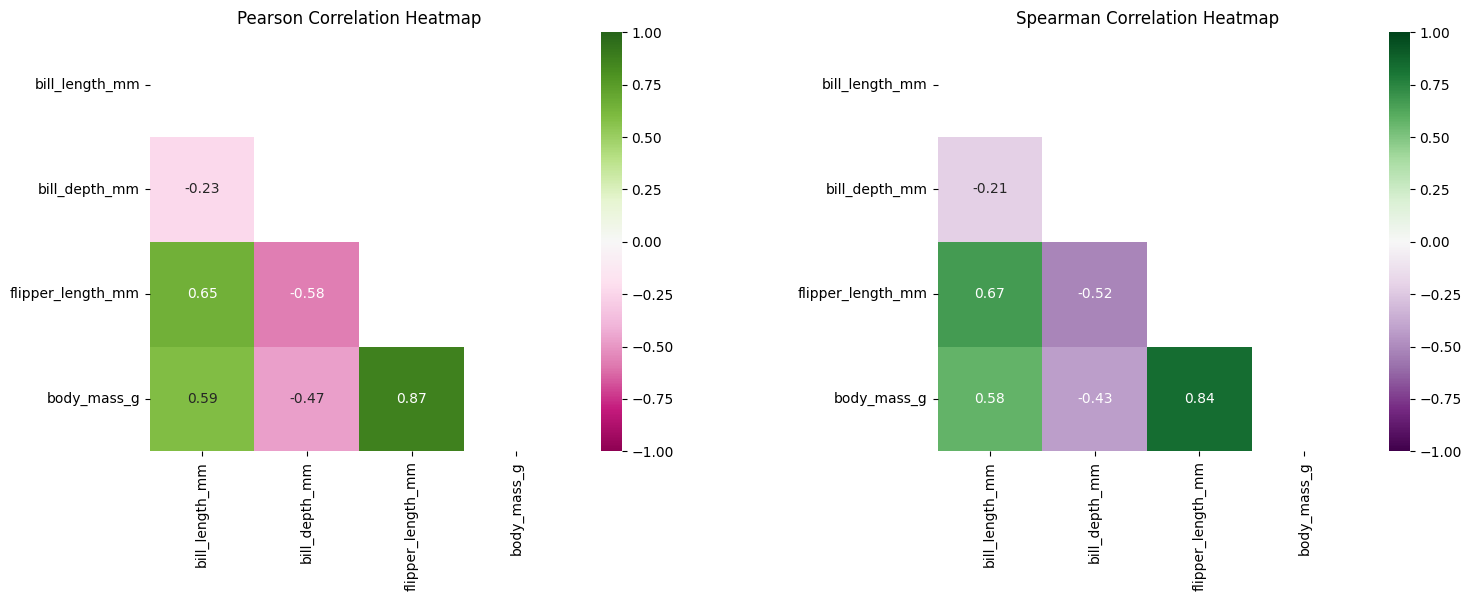

In [119]:
mask=np.triu(np.ones_like(pearson_corr,dtype=bool))
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))
sns.heatmap(pearson_corr,mask=mask,annot=True,fmt=".2f",cmap="PiYG",vmin=-1,vmax=1,center=0,square=True,ax=ax1)
ax1.set_title('Pearson Correlation Heatmap')
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt=".2f", cmap="PRGn", vmin=-1, vmax=1, center=0, square=True, ax=ax2)
ax2.set_title('Spearman Correlation Heatmap')

plt.tight_layout()
plt.show()

**Where do they agree?**

The Pearson and Spearman heatmaps show a very high level of agreement.

**Where do they differ, and what does that tell you about the shape of those relationships?**

There are no significant discrepancies between the two matrices. This close alignment tells us several important things about the data's "shape":

- Linearity: The relationships between the penguins' physical traits are almost entirely linear. Since Spearman (which measures any monotonic trend) isn't noticeably higher than Pearson (which only measures straight-line trends), we can conclude the variables move together in a straight line.

- Lack of Outliers: Pearson is highly sensitive to outliers, while Spearman is robust. The fact that their values are nearly identical suggests there are no extreme outliers in the dataset distorting the results.

- Consistency: The biological growth patterns of these penguins are very consistent across the sampled population.

## Task 3: Scatterplot Analysis of Key Pairs

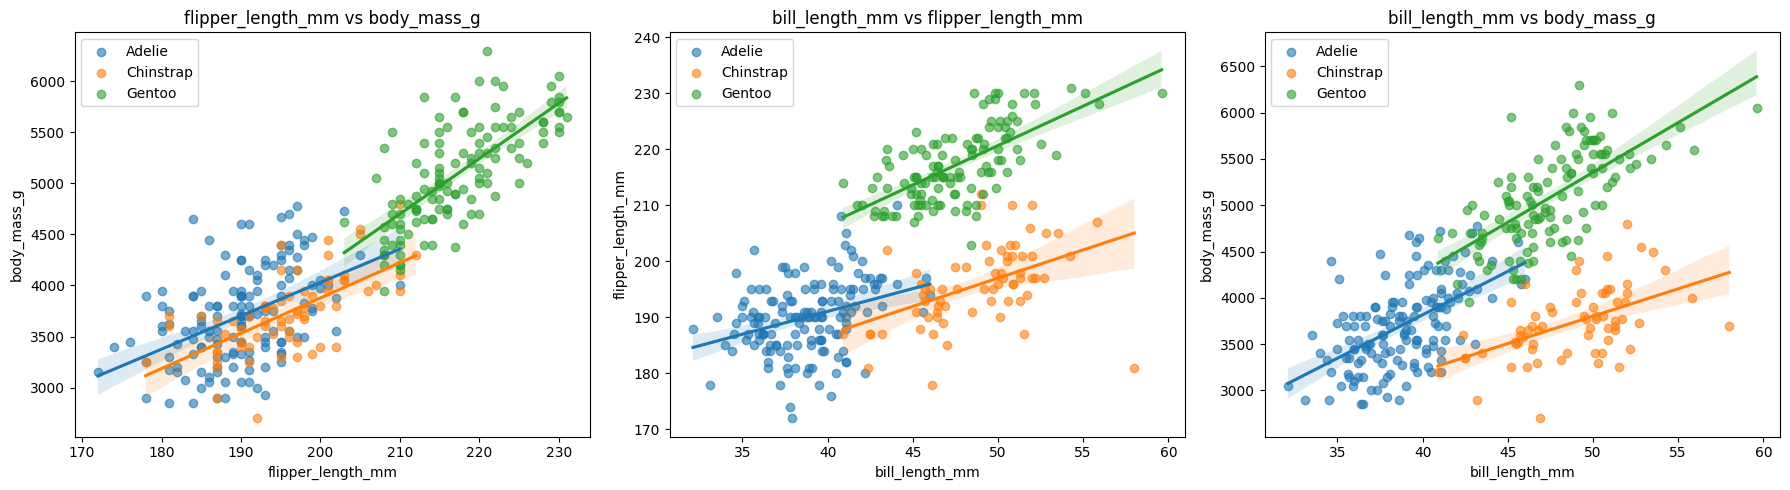

In [120]:
pairs = [
    ('flipper_length_mm', 'body_mass_g'),
    ('bill_length_mm', 'flipper_length_mm'),
    ('bill_length_mm', 'body_mass_g')
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (col1, col2) in enumerate(pairs):
    for species in df_clean['species'].unique():
        subset = df_clean[df_clean['species'] == species]
        sns.regplot(data=subset, x=col1, y=col2, ax=axes[i], label=species, scatter_kws={'alpha':0.6})    
    axes[i].set_title(f'{col1} vs {col2}')
    axes[i].legend() 
plt.tight_layout()
plt.show()

**Does the regression line capture the actual pattern well?**

Yes, the regression lines capture the overall pattern quite effectively, especially for pairs like flipper_length_mm vs body_mass_g. The points are closely clustered around the lines, and the narrow confidence intervals (the shaded areas) indicate that the linear model is a strong fit for this biological data. The high Pearson correlation ($0.87$) we saw earlier is visually confirmed by how well these lines track the data points. 

**Do subgroups show different slopes or intercepts?**

- Intercepts: Yes, there are clear differences in intercepts. For example, in the bill_length_mm vs flipper_length_mm plot, the Gentoo species (green) is shifted significantly higher and to the right compared to Adelie (blue) and Chinstrap (orange). This shows that Gentoo penguins are fundamentally larger birds regardless of the specific measurement.

- Slopes: The slopes are mostly similar (parallel) for the top 3 pairs, meaning that as one body part grows, the other increases at a similar rate across all species. However, if we were to look at bill_depth, we would see a classic Simpson’s Paradox: the overall slope might appear negative or flat, but within each species, the slope is actually positive. This highlights the importance of grouping by species to avoid misleading conclusions.